In [1]:
# ============================================================
# Notebook 03 — Entrenamiento del modelo LSTM
# Sistema de detección de apnea del sueño
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ Librerías cargadas correctamente")

✓ TensorFlow version: 2.21.0
✓ Librerías cargadas correctamente


In [2]:
# ============================================================
# Cargar datos preprocesados del Notebook 02
# ============================================================

ruta = Path('../data/simulated')

X_train = np.load(ruta / 'X_train.npy')
X_val   = np.load(ruta / 'X_val.npy')
X_test  = np.load(ruta / 'X_test.npy')
y_train = np.load(ruta / 'y_train.npy')
y_val   = np.load(ruta / 'y_val.npy')
y_test  = np.load(ruta / 'y_test.npy')

print(f"✓ X_train: {X_train.shape}")
print(f"✓ X_val:   {X_val.shape}")
print(f"✓ X_test:  {X_test.shape}")
print(f"✓ y_train: {y_train.shape}")

✓ X_train: (420, 300, 1)
✓ X_val:   (90, 300, 1)
✓ X_test:  (90, 300, 1)
✓ y_train: (420,)


In [3]:
# ============================================================
# Arquitectura del modelo LSTM
# ============================================================

modelo = Sequential([
    LSTM(64, return_sequences=True, input_shape=(300, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # 3 clases
])

modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

D:\Nuvia2\apnea-detection\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 300, 64)             │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 300, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,891 (116.76 KB)

 Trainable params: 29,891 (116.76 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ============================================================
# Entrenamiento
# ============================================================

# EarlyStopping detiene el entrenamiento si deja de mejorar
# ModelCheckpoint guarda automáticamente el mejor modelo
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='../model/mejor_modelo.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Iniciando entrenamiento...")
print("Esto puede tardar unos minutos...\n")

historial = modelo.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

print("\n✓ Entrenamiento completado")

Iniciando entrenamiento...
Esto puede tardar unos minutos...

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.4571 - loss: 1.0863
Epoch 1: val_accuracy improved from None to 0.50000, saving model to ../model/mejor_modelo.keras

Epoch 1: finished saving model to ../model/mejor_modelo.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 303ms/step - accuracy: 0.4786 - loss: 1.0745 - val_accuracy: 0.5000 - val_loss: 1.0573
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.4985 - loss: 1.0520
Epoch 2: val_accuracy did not improve from 0.50000
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.5000 - loss: 1.0574 - val_accuracy: 0.5000 - val_loss: 1.0517
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5055 - loss: 1.0519
Epoch 3: val_accuracy did not improve from 0.50000
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.5000 - loss: 1.0526 - val_accuracy: 0.5000 - val_loss: 1.0485
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.5

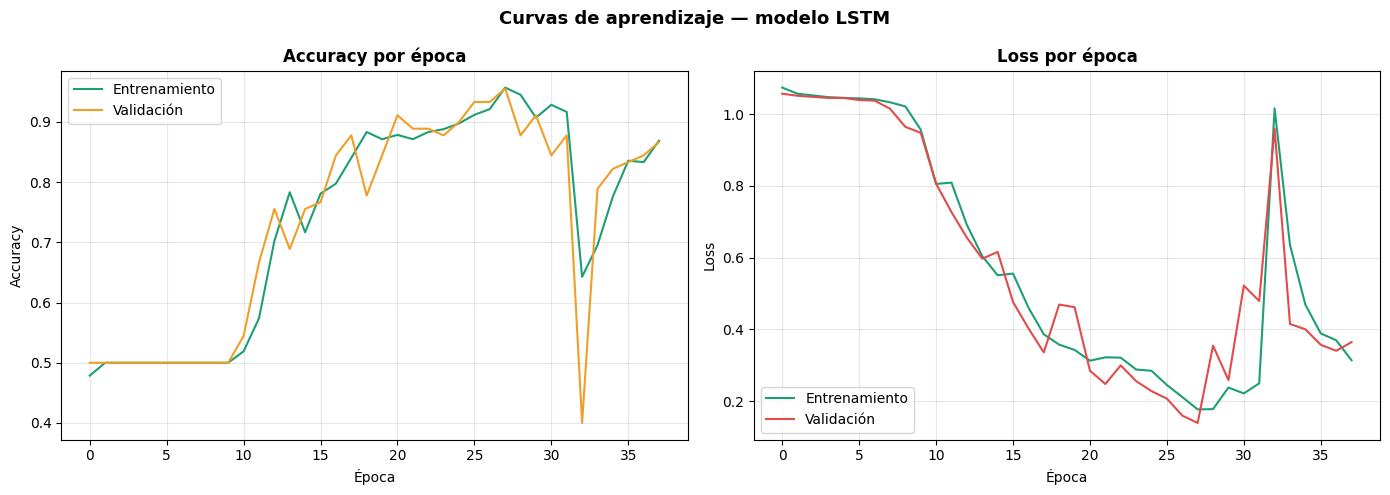

✓ Gráficas guardadas


In [5]:
# ============================================================
# Gráficas de entrenamiento
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(historial.history['accuracy'],     color='#1D9E75', label='Entrenamiento')
axes[0].plot(historial.history['val_accuracy'], color='#EF9F27', label='Validación')
axes[0].set_title('Accuracy por época', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(historial.history['loss'],     color='#1D9E75', label='Entrenamiento')
axes[1].plot(historial.history['val_loss'], color='#E24B4A', label='Validación')
axes[1].set_title('Loss por época', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje — modelo LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/simulated/curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráficas guardadas")

In [6]:
# ============================================================
# Evaluación final con datos de prueba
# ============================================================

loss, accuracy = modelo.evaluate(X_test, y_test, verbose=0)

print(f"✓ Loss en prueba:     {loss:.4f}")
print(f"✓ Accuracy en prueba: {accuracy:.4f} ({accuracy*100:.1f}%)")

✓ Loss en prueba:     0.1514
✓ Accuracy en prueba: 0.9333 (93.3%)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step


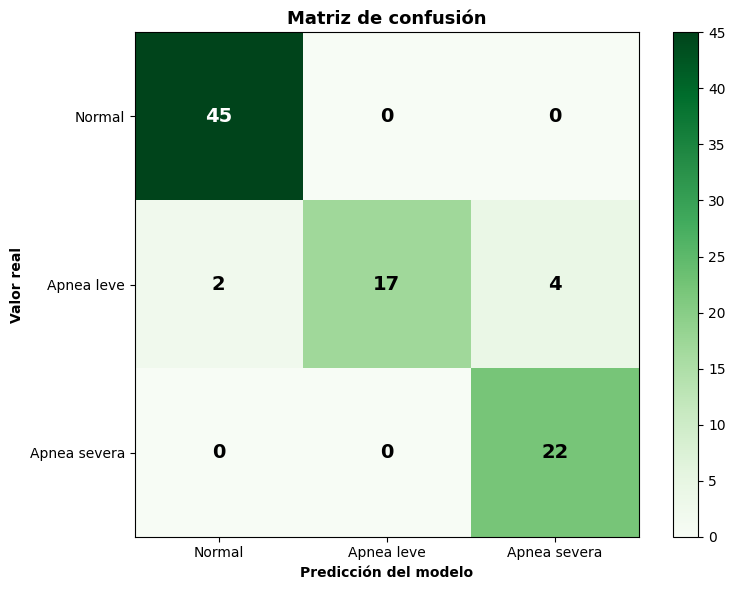


               precision    recall  f1-score   support

      Normal       0.96      1.00      0.98        45
  Apnea leve       1.00      0.74      0.85        23
Apnea severa       0.85      1.00      0.92        22

    accuracy                           0.93        90
   macro avg       0.93      0.91      0.91        90
weighted avg       0.94      0.93      0.93        90



In [7]:
# ============================================================
# Matriz de confusión
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = np.argmax(modelo.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

# Visualizar
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Greens')
plt.colorbar(im)

clases = ['Normal', 'Apnea leve', 'Apnea severa']
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(clases)
ax.set_yticklabels(clases)

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicción del modelo', fontweight='bold')
ax.set_ylabel('Valor real', fontweight='bold')
ax.set_title('Matriz de confusión', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/simulated/matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n", classification_report(y_test, y_pred, target_names=clases))

In [8]:
# ============================================================
# Exportar a TensorFlow Lite
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(modelo)
tflite_model = converter.convert()

ruta_tflite = Path('../model/modelo_apnea.tflite')
with open(ruta_tflite, 'wb') as f:
    f.write(tflite_model)

tamanio = ruta_tflite.stat().st_size / 1024
print(f"✓ Modelo exportado a modelo_apnea.tflite")
print(f"✓ Tamaño del archivo: {tamanio:.1f} KB")
print(f"✓ Listo para usar en la app móvil")


INFO:tensorflow:Assets written to: C:\Users\Leone\AppData\Local\Temp\tmpgzdbis6j\assets


INFO:tensorflow:Assets written to: C:\Users\Leone\AppData\Local\Temp\tmpgzdbis6j\assets


Saved artifact at 'C:\Users\Leone\AppData\Local\Temp\tmpgzdbis6j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1937360914768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360916496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360915536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360916880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360917072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360917264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360916688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360915920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360914960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360917456: TensorSpec(shape=(), dtype=tf.resource, name=None)


ConverterError: <unknown>:0: error: loc(callsite(fused["TensorListReserve:", "sequential_1/lstm_1/TensorArrayV2_1@__inference_function_10961"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_11012"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_11012"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: error: loc(callsite(fused["TensorListReserve:", "sequential_1/lstm_1/TensorArrayV2_1@__inference_function_10961"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_11012"] at fused["StatefulPartitionedCall:"

In [9]:
# ============================================================
# Exportar a TensorFlow Lite
# ============================================================

converter = tf.lite.TFLiteConverter.from_keras_model(modelo)

# Configuración necesaria para modelos con capas LSTM
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

ruta_tflite = Path('../model/modelo_apnea.tflite')
with open(ruta_tflite, 'wb') as f:
    f.write(tflite_model)

tamanio = ruta_tflite.stat().st_size / 1024
print(f"✓ Modelo exportado a modelo_apnea.tflite")
print(f"✓ Tamaño del archivo: {tamanio:.1f} KB")
print(f"✓ Listo para usar en la app móvil")

INFO:tensorflow:Assets written to: C:\Users\Leone\AppData\Local\Temp\tmp0kqsxbfn\assets


INFO:tensorflow:Assets written to: C:\Users\Leone\AppData\Local\Temp\tmp0kqsxbfn\assets


Saved artifact at 'C:\Users\Leone\AppData\Local\Temp\tmp0kqsxbfn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1937360914768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360916496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360915536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360916880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360917072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360917264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360916688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360915920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360914960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1937360917456: TensorSpec(shape=(), dtype=tf.resource, name=None)
✓ Modelo exp

In [2]:
import serial
import time

# Conectar al Arduino
arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)  # esperar que el Arduino inicialice

print("Leyendo datos del Arduino... (10 lecturas)")
print("-" * 30)

for _ in range(10):
    linea = arduino.readline().decode('utf-8').strip()
    if linea:
        print(f"Valor sensor: {linea}")

arduino.close()
print("-" * 30)
print("✓ Conexión exitosa")

Leyendo datos del Arduino... (10 lecturas)
------------------------------
Valor sensor:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [3]:
import serial
import time

arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)

print("Dobla y suelta el sensor mientras lees...")
print("-" * 30)

for _ in range(30):
    linea = arduino.readline().decode('utf-8').strip()
    if linea and linea != 'INICIO':
        print(f"Valor: {linea}")

arduino.close()
print("-" * 30)
print("✓ Prueba completada")

Dobla y suelta el sensor mientras lees...
------------------------------
Valor: 56
Valor: 51
Valor: 64
Valor: 71
Valor: 73
Valor: 61
Valor: 57
Valor: 56
Valor: 53
Valor: 53
Valor: 52
Valor: 53
Valor: 66
Valor: 64
Valor: 48
Valor: 54
Valor: 49
Valor: 49
Valor: 46
Valor: 48
Valor: 45
Valor: 48
Valor: 48
Valor: 48
Valor: 46
Valor: 47
Valor: 47
Valor: 69
Valor: 82
------------------------------
✓ Prueba completada


Coloca el sensor en tu abdomen y respira normal...
Recolectando 30 segundos de señal real...
------------------------------


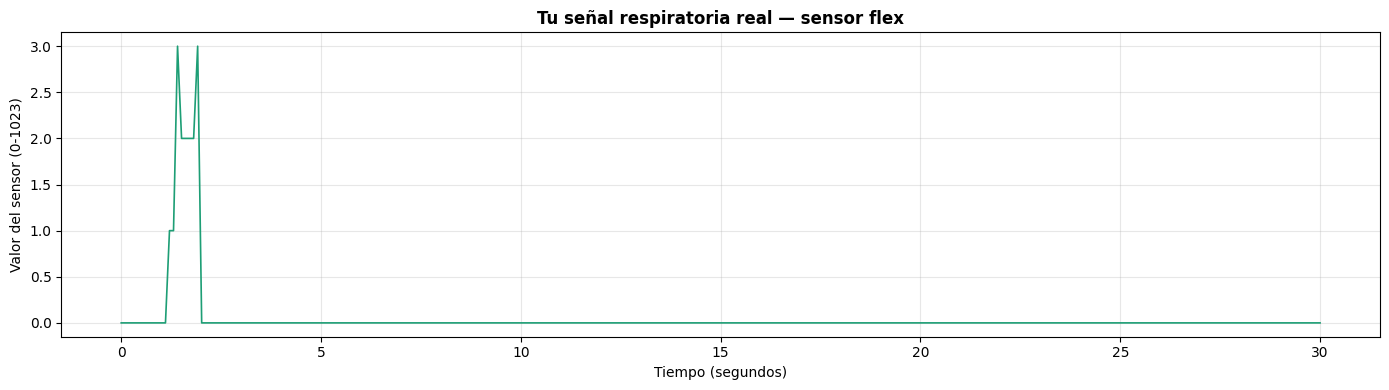

✓ 299 lecturas capturadas
✓ Valor mínimo: 0
✓ Valor máximo: 3
✓ Rango: 3


In [11]:
import serial
import time
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import deque

arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)

print("Coloca el sensor en tu abdomen y respira normal...")
print("Recolectando 30 segundos de señal real...")
print("-" * 30)

valores = []
for _ in range(300):  # 300 lecturas = 30 segundos a 10Hz
    linea = arduino.readline().decode('utf-8').strip()
    if linea and linea != 'INICIO':
        try:
            valores.append(int(linea))
        except:
            pass

arduino.close()

# Graficar la señal
import numpy as np
t = np.linspace(0, 30, len(valores))

plt.figure(figsize=(14, 4))
plt.plot(t, valores, color='#1D9E75', linewidth=1.2)
plt.title('Tu señal respiratoria real — sensor flex', fontweight='bold')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Valor del sensor (0-1023)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/real/primera_senal_real.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ {len(valores)} lecturas capturadas")
print(f"✓ Valor mínimo: {min(valores)}")
print(f"✓ Valor máximo: {max(valores)}")
print(f"✓ Rango: {max(valores) - min(valores)}")

In [16]:
import serial
import time

arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)

print("Leyendo valores actuales...")
print("-" * 30)

for _ in range(20):
    linea = arduino.readline().decode('utf-8').strip()
    if linea and linea != 'INICIO':
        print(f"Valor: {linea}")

arduino.close()

Leyendo valores actuales...
------------------------------
Valor: 65
Valor: 65
Valor: 62
Valor: 60
Valor: 41
Valor: 37
Valor: 50
Valor: 53
Valor: 57
Valor: 53
Valor: 47
Valor: 49
Valor: 45
Valor: 40
Valor: 32
Valor: 22
Valor: 51
Valor: 62
Valor: 77


In [2]:
import serial
import time

arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)

print("Respira normal 15 segundos con el sensor en el abdomen...")
valores = []

for _ in range(150):
    linea = arduino.readline().decode('utf-8').strip()
    if linea and linea != 'INICIO':
        try:
            valores.append(int(linea))
        except:
            pass

arduino.close()

print(f"✓ Valor mínimo (exhalar): {min(valores)}")
print(f"✓ Valor máximo (inhalar): {max(valores)}")
print(f"✓ Rango actual:           {max(valores) - min(valores)}")
print(f"✓ Promedio:               {sum(valores)//len(valores)}")

Respira normal 15 segundos con el sensor en el abdomen...
✓ Valor mínimo (exhalar): 0
✓ Valor máximo (inhalar): 16
✓ Rango actual:           16
✓ Promedio:               4


Respira normal 30 segundos...


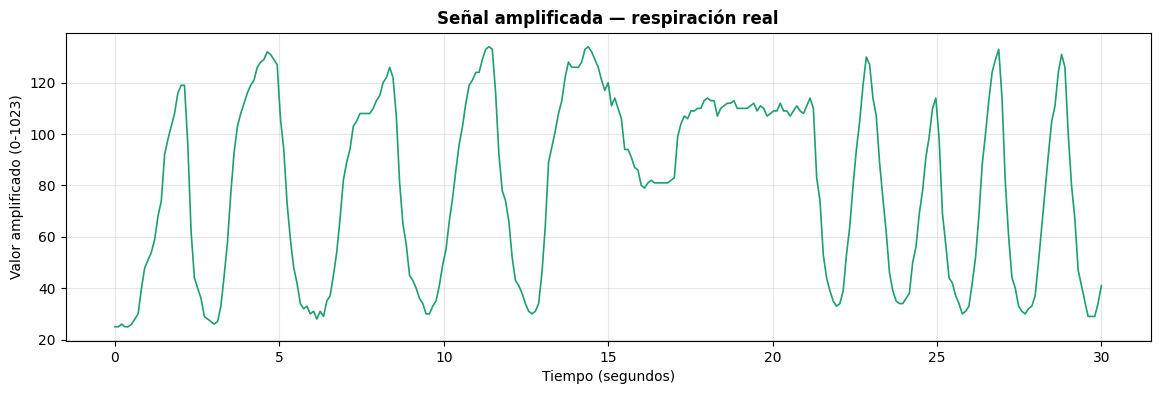

✓ Rango actual: 25 — 134
✓ Amplitud:     109


In [17]:
import serial
import time
import numpy as np
import matplotlib.pyplot as plt

arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)

print("Respira normal 30 segundos...")
valores = []

for _ in range(300):
    linea = arduino.readline().decode('utf-8').strip()
    if linea and linea != 'INICIO':
        try:
            valores.append(int(linea))
        except:
            pass

arduino.close()

t = np.linspace(0, 30, len(valores))
plt.figure(figsize=(14, 4))
plt.plot(t, valores, color='#1D9E75', linewidth=1.2)
plt.title('Señal amplificada — respiración real', fontweight='bold')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Valor amplificado (0-1023)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"✓ Rango actual: {min(valores)} — {max(valores)}")
print(f"✓ Amplitud:     {max(valores) - min(valores)}")

In [18]:
import serial
import time

arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)

print("Respira normal 20 segundos — no te muevas mucho...")
valores = []

for _ in range(200):
    linea = arduino.readline().decode('utf-8').strip()
    if linea and linea != 'INICIO':
        try:
            v = int(linea)
            valores.append(v)
            print(f"Valor raw: {v}")
        except:
            pass

arduino.close()

print(f"\n✓ Mínimo real: {min(valores)}")
print(f"✓ Máximo real: {max(valores)}")

Respira normal 20 segundos — no te muevas mucho...
Valor raw: 6
Valor raw: 6
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 11
Valor raw: 13
Valor raw: 8
Valor raw: 8
Valor raw: 5
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 1
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 0
Valor raw: 21
Valor raw: 30
Valor raw: 33
Valor raw: 32
Valor raw: 36
Valor raw: 40
Valor raw: 18
Valor raw: 33
Valor raw: 37
Valor raw: 38
Valor raw: 40
Valor raw: 46
Valor raw: 59
Valor raw: 72
Valor raw: 80
Valor raw: 75
Valor raw: 78
Valor raw: 80
Valor raw: 80
Valor raw: 81
Valor raw: 82
Valor raw: 81
Valor raw: 74
Valor raw: 78
Valor raw: 81
Valor raw: 82
Valor raw: 

In [11]:
import serial
import time

arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)

print("Inhala profundo y exhala completo — repite 10 veces...")
valores = []

for _ in range(200):
    linea = arduino.readline().decode('utf-8').strip()
    if linea and linea != 'INICIO':
        try:
            v = int(linea)
            valores.append(v)
        except:
            pass

arduino.close()

print(f"✓ Mínimo (exhalar):  {min(valores)}")
print(f"✓ Máximo (inhalar):  {max(valores)}")
print(f"✓ Rango real:        {max(valores) - min(valores)}")

Inhala profundo y exhala completo — repite 10 veces...
✓ Mínimo (exhalar):  0
✓ Máximo (inhalar):  104
✓ Rango real:        104


Haz esto en orden:
1. Respira normal 10 segundos
2. Aguanta la respiración 10 segundos (simula apnea)
3. Respira normal 10 segundos
------------------------------


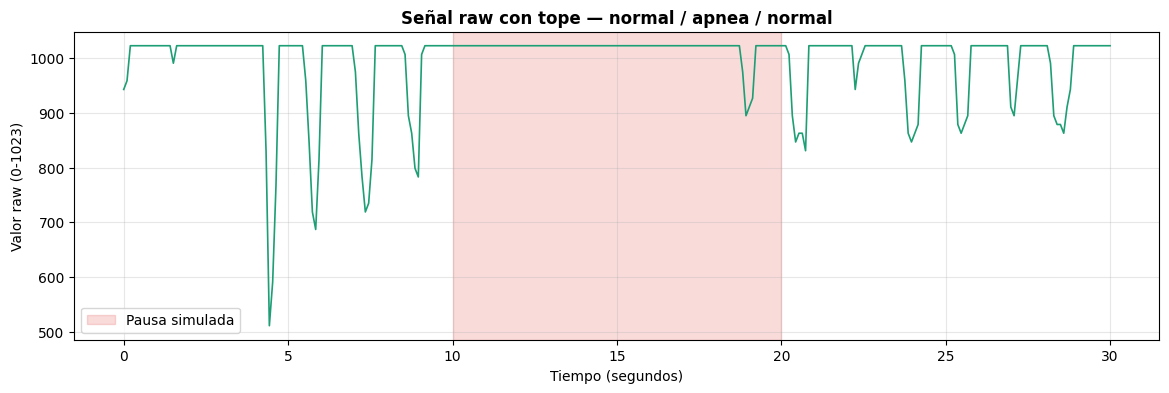

✓ Mínimo: 511
✓ Máximo: 1023
✓ Rango:  512


In [24]:
import serial
import time

arduino = serial.Serial('COM3', 9600, timeout=2)
time.sleep(2)

print("Haz esto en orden:")
print("1. Respira normal 10 segundos")
print("2. Aguanta la respiración 10 segundos (simula apnea)")
print("3. Respira normal 10 segundos")
print("-" * 30)

valores = []
for _ in range(300):
    linea = arduino.readline().decode('utf-8').strip()
    if linea and linea != 'INICIO':
        try:
            v = int(linea)
            valores.append(v)
        except:
            pass

arduino.close()

import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 30, len(valores))
plt.figure(figsize=(14, 4))
plt.plot(t, valores, color='#1D9E75', linewidth=1.2)
plt.axvspan(10, 20, color='#E24B4A', alpha=0.2, label='Pausa simulada')
plt.title('Señal raw con tope — normal / apnea / normal', fontweight='bold')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Valor raw (0-1023)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"✓ Mínimo: {min(valores)}")
print(f"✓ Máximo: {max(valores)}")
print(f"✓ Rango:  {max(valores) - min(valores)}")